# 检查语言output能力

In [8]:
import os
import sys
# NOTE enable this in single script
# current_file_path = os.path.dirname(os.path.abspath(__file__))
# module_path = os.path.join(current_file_path, "../..")
# sys.path.append(module_path)
from dataclasses import asdict
import math
from pathlib import Path
from typing import List, Optional
import yaml
import debugpy

from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import torch
import transformers
from transformers import Trainer, is_datasets_available
import datasets
from transformers.integrations import deepspeed
from torch.utils.data import Dataset, ConcatDataset, WeightedRandomSampler, RandomSampler, DataLoader

from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from models.qwen2_5_vl import Qwen2_5_VLRetForConditionalGeneration

from arguments import ModelArguments, DataArguments, TrainingArguments, LoraArguments
from collators import COLLATORS
from dataset.datasets_mbeir import LazySupervisedDataset, MbeirLanguageDataset
from dataset.datasets_xhs import XHSDataset
from dataset.datasets_dam import DAMDataset
# from dataset.datasets_mmeb import MMEBDataset
from loaders import LOADERS
from supported_models import MODULE_KEYWORDS
from utils import (
    rank0_print
)
    
# model = Qwen2_5_VLForConditionalGeneration.from_pretrained("./checkpoints/Qwen2.5-VL-7B-Dam", attn_implementation= "flash_attention_2", torch_dtype=torch.bfloat16, low_cpu_mem_usage=True).cuda()
model = Qwen2_5_VLRetForConditionalGeneration.from_pretrained("./checkpoints/Qwen2.5-VL-7B-Dam", attn_implementation= "flash_attention_2", torch_dtype=torch.bfloat16, low_cpu_mem_usage=True).cuda()
# model = Qwen2_5_VLRetForConditionalGeneration.from_pretrained("./checkpoints/qwen2_5-vl-7b_DAM_pretrain_vision", attn_implementation= "flash_attention_2", torch_dtype=torch.bfloat16, low_cpu_mem_usage=True).cuda()
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")
# processor = AutoProcessor.from_pretrained("./checkpoints/qwen2_5-vl-7b_DAM_pretrain_vision")
tokenizer = processor.tokenizer 



Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  7.13it/s]


In [5]:
i=-1
# model.visual.context_layers[i].mlp_factor
model.visual.context_layers[i].mlp_factor

Parameter containing:
tensor(0.0894, device='cuda:0', dtype=torch.bfloat16, requires_grad=True)

In [11]:
dam_dataset = DAMDataset(
    data_path="/mnt/tidal-alsh01/dataset/mmeb/describe-anything-data",
    max_length=10000,
    mode='crop'
)

data_collator = COLLATORS['qwen2_5-vl-7b'](
    tokenizer=tokenizer,
    processor=processor,
)

dataloader = DataLoader(dam_dataset, batch_size=1, num_workers=2, shuffle=False, collate_fn=data_collator)
dataloader = iter(dataloader)

device = 'cuda:0'

def tensors_to_device(data, device, dtype=model.dtype):
    for key in data.keys():
        if isinstance(data[key], torch.Tensor):
            if key == 'pixel_values':
                data[key] = data[key].to(device).to(dtype)
            else:
                data[key] = data[key].to(device)
    return data 


model.to(device)
model.eval()
model.config.emb_token_ids = [-777]

# TODO : 跑之前要把dam ds返回的改成1
datalist = [d for d,i in zip(dataloader, range(10))]

with torch.no_grad():
    for i, data in enumerate(datalist):
        # data = next(dataloader)
        batch = tensors_to_device(data, device)
        output = model.generate(**batch, max_new_tokens=512)
        image_generated_ids = output
        image_input_length = batch['input_ids'].shape[1]
        image_generated_only_ids = image_generated_ids[:, image_input_length:]

        # 解码生成的 token IDs 为文本
        # `skip_special_tokens=True` 会移除像 <|endoftext|> 这样的特殊标记
        image_decoded_outputs = tokenizer.batch_decode(image_generated_ids, skip_special_tokens=True)
        print("@decode inputs:" ,image_decoded_outputs)

The segmented image shows two wooden walls. The first wall, on the left, is a light brown wood with horizontal grooves and a smooth finish. The second wall, on the right, is a darker brown wood with a glossy finish, featuring multiple evenly spaced metal h
A vibrant red textile with a smooth texture, prominently featuring a white geometric pattern consisting of interlocking lines forming a complex design. The textile is draped vertically and appears to be part of a larger fabric.
A neatly folded, rectangular white napkin with a smooth texture, positioned flat on a surface. The napkin is partially covered by a metallic fork with a shiny finish, placed diagonally across the napkin.
Multiple thin, dark brown branches with smooth surfaces and no leaves. The branches are slender and slightly curved, with some smaller twigs extending from the main branches. The branches intersect and overlap, creating a network of thin lines. The tips of
The playing field consists of a well-maintained grass 

The net is a rectangular mesh structure with a black grid pattern, supported by a white vertical post in the center. The top of the net is lined with a white horizontal band.


{'img_id': '000000000531', 'ann_id': 10000559, 'image': 'coco/train2017/000000000531.jpg', 'category': 'net', 'caption': 'The net is a white horizontal band supported by black vertical posts. It spans across the width of the tennis court, dividing it into two equal halves. The net is taut and evenly suspended, with a slight sag in the middle.', 'mask_rle': {'counts': '[cP11c>3`A2^>;M2O3M1N8I01O00O11N02N1001O000N3O0O5YOjA<_>A_A;c>0000N2N2N2O1N2OdS6O^lI2M100O10001BOjA1V>4fAMY>=00M]OiAc0T>6G]OTBf0j=9O2OO01N11O000000001N010000001O001TOVB`0n=WOUB0Nh0X>M000O1000000000000000000000000OM4G@RB`0k=<M300001O001O00O11O0O100000O14L1O6QOlAf0W>ZOhAd0Z>01O00O010000000001OO1000O10001OO11O1OO11O0000000000O12NO11O000O01N2O1O10DeA3[>JhA6b>O00LGaA8]>7M3N22N000000001O2N1O1O0101N1bA@Y>d0000O10000000001O0000O1O1000^OhA<^>O0DaAOO0gZa07ST_ONWAKh>44MA5:2L5O2K2O000000000M3M\\OjAd0V>\\OjAd0V>3HYOSB0Ni0n=XORBl0o=SOQBm0n=22OO1002NO1O100000000O1O1001N0100000000O11OO1000O10O10000001O1N101O0000O11O000O11OO100000000000O0

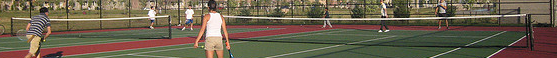

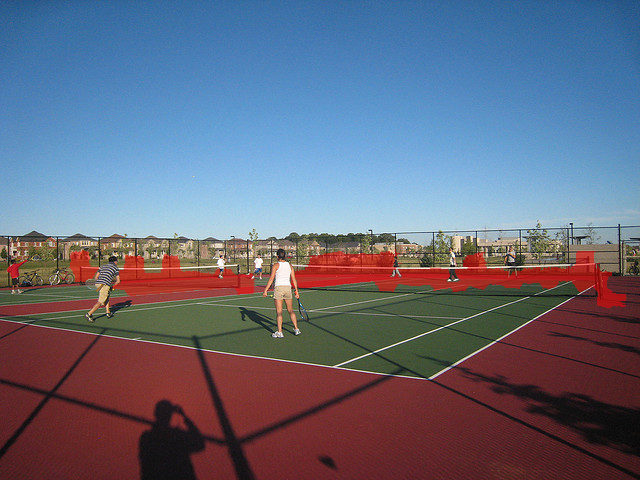

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pycocotools
from PIL import Image
import pickle

def counts_to_mask(maskrle):
    return np.array(pycocotools.mask.decode(maskrle), dtype=np.float32)

def visualize_mask_on_image_pil(original_pil, binary_mask_np, 
                                color=(255, 0, 0), alpha_percent=50):
    height, width = binary_mask_np.shape
    if original_pil.size != (width, height):
        print(f"Warning: Mask size ({width},{height}) and image size ({original_pil.size}) differ.")
    alpha_value = int((alpha_percent / 100.0) * 255)
    colored_mask_pil = Image.new("RGBA", original_pil.size, (0, 0, 0, 0))
    mask_rgba_np = np.zeros((height, width, 4), dtype=np.uint8)
    
    mask_indices = binary_mask_np == 1
    mask_rgba_np[mask_indices] = list(color) + [alpha_value]

    colored_mask_pil_from_np = Image.fromarray(mask_rgba_np, "RGBA")
    original_pil.putalpha(255)
    overlaid_image_pil = Image.alpha_composite(original_pil, colored_mask_pil_from_np)    
    return overlaid_image_pil

def mask2box(mask):
    box = None
    pos = np.where(mask > 0)
    height, width = mask.shape

    if pos[0].size > 0 and pos[1].size > 0:
        x_min = np.min(pos[1]) / width
        x_max = np.max(pos[1]) / width
        y_min = np.min(pos[0]) / height
        y_max = np.max(pos[0]) / height
        box = [x_min, y_min, x_max, y_max]
    return box


dataset = dam_dataset.dataset['COCOStuff']['train']
idx = (19,0)
anno = pickle.loads(dataset[idx[0]]['pickle'])
print(anno[idx[1]])
mask = counts_to_mask(anno[idx[1]]['mask_rle'])
box = mask2box(mask)
# print(anno[idx[1]]['category'])
# print(anno[idx[1]]['caption'])
img = dataset[idx[0]]['jpg']
print(box)
width, height = img.size
x0 = width * box[0]
y0 = height * box[1]
x1 = width * box[2]
y1 = height * box[3]

img.crop((x0, y0, x1, y1)).show()
visualize_mask_on_image_pil(img, mask)

In [23]:
mask
pos = np.where(mask > 0)

In [25]:
np.max(pos[0])

307

In [28]:
img.size

(640, 480)

In [29]:
mask.shape

(480, 640)